# Task 2: Model Interpretation and Business Report

**Objective:** Interpret the model chosen in Task 1 using feature importance, then turn the
technical findings into a short business report covering the key drivers, risks, limitations and
recommended actions.

**Model being interpreted:** the Random Forest from Task 1, which scored 0.9458 accuracy and
0.9888 ROC-AUC. It is rebuilt here with the same settings and the same random seed so the numbers
match.

A model that predicts well but cannot be explained is hard to trust and hard to act on. This
notebook answers two questions: **which factors does the model rely on**, and **which direction
does each one push**.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Rebuild the Data and the Model

The same steps as Task 1: fill missing values, create the five features, build the target, split
the data, train the Random Forest. Nothing new happens here, it just recreates the model so it can
be examined.

In [2]:
df = pd.read_csv("data/sales_data.csv")

# missing values
df["Product Base Margin"] = df.groupby("Product Category")["Product Base Margin"].transform(
    lambda s: s.fillna(s.median())
)

# feature engineering (same five features as Task 1)
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df["Shipping Delay"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Revenue Per Unit"] = df["Sales"] / df["Order Quantity"]
df["Shipping Cost Ratio"] = df["Shipping Cost"] / df["Sales"]
df["Discount Value"] = df["Sales"] * df["Discount"]
df["Order Month"] = df["Order Date"].dt.month

# target
df["Profitable"] = (df["Profit"] > 0).astype(int)

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Shape: (8399, 27)
Missing values: 0


In [3]:
numeric_features = ["Order Quantity", "Sales", "Discount", "Unit Price",
                    "Shipping Cost", "Product Base Margin",
                    "Shipping Delay", "Revenue Per Unit", "Shipping Cost Ratio",
                    "Discount Value", "Order Month"]

categorical_features = ["Order Priority", "Ship Mode", "Region", "Customer Segment",
                        "Product Category", "Product Sub-Category", "Product Container"]

X = df[numeric_features + categorical_features]
y = df["Profitable"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, proba), 4))
print()
print("These match the Task 1 results, so the model is the same one.")

Accuracy: 0.9458
ROC-AUC : 0.9888

These match the Task 1 results, so the model is the same one.


## 3. Feature Importance

Random Forest can report how much each feature contributed to its decisions. Higher importance
means the model relied on that feature more.

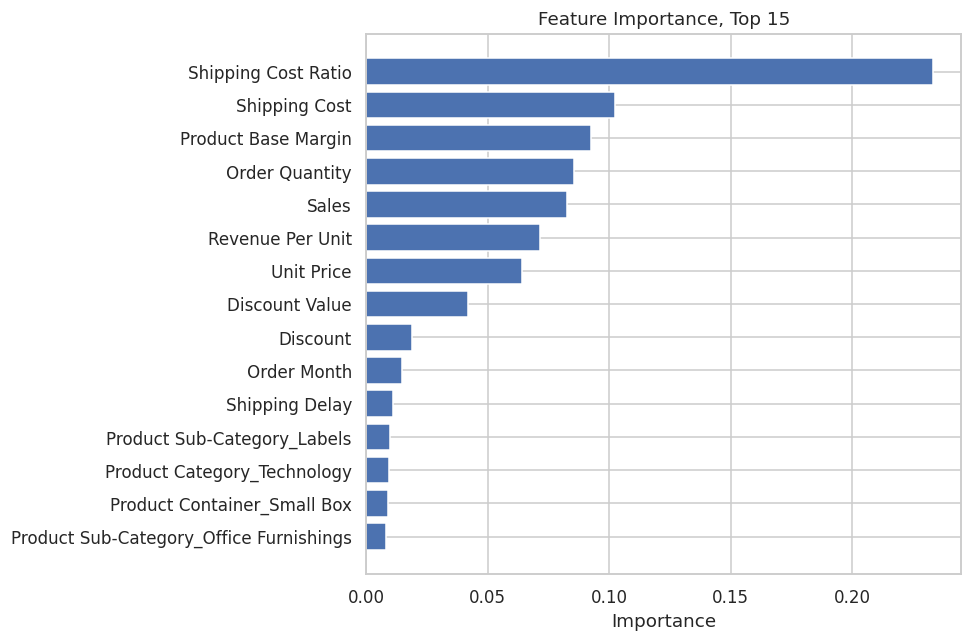

            Feature  Importance
Shipping Cost Ratio      0.2334
      Shipping Cost      0.1023
Product Base Margin      0.0925
     Order Quantity      0.0853
              Sales      0.0824
   Revenue Per Unit      0.0716
         Unit Price      0.0641
     Discount Value      0.0419
           Discount      0.0187
        Order Month      0.0148


In [4]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
clean_names = [n.replace("num__", "").replace("cat__", "") for n in feature_names]
importances = model.named_steps["model"].feature_importances_

imp = (pd.DataFrame({"Feature": clean_names, "Importance": importances})
       .sort_values("Importance", ascending=False)
       .reset_index(drop=True))

top15 = imp.head(15).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(top15["Feature"], top15["Importance"], color="#4C72B0")
plt.title("Feature Importance, Top 15")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("screenshots/01_feature_importance.png", bbox_inches="tight")
plt.show()

print(imp.head(10).round(4).to_string(index=False))

### Observation
**`Shipping Cost Ratio` is by far the most important feature**, well ahead of everything else. This
is one of the five features created in Task 1, which means the feature engineering did not just
improve the score, it produced the single most useful input the model has.

Four of the top ten features (`Shipping Cost Ratio`, `Revenue Per Unit`, `Discount Value` and
`Order Month`) are ones that were created rather than supplied with the dataset.

## 4. Engineered Features vs Original Features

Grouping the importances shows how much of the model's decision making rests on the new features.

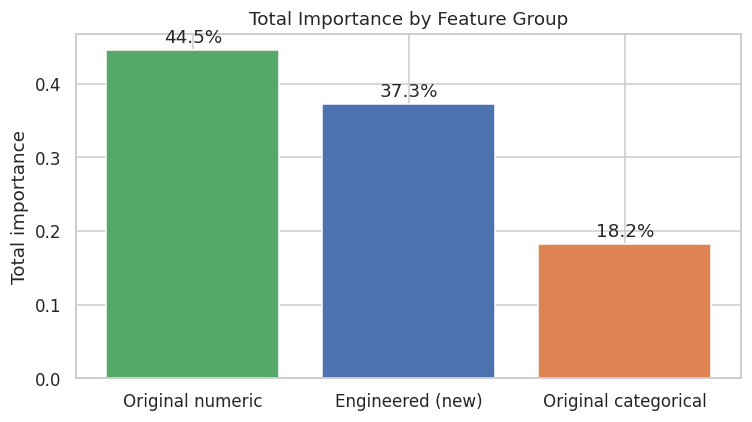

Group
Original numeric        0.4454
Engineered (new)        0.3726
Original categorical    0.1821
Name: Importance, dtype: float64


In [5]:
engineered = ["Shipping Delay", "Revenue Per Unit", "Shipping Cost Ratio",
              "Discount Value", "Order Month"]

def group_of(name):
    if name in engineered:
        return "Engineered (new)"
    if name in numeric_features:
        return "Original numeric"
    return "Original categorical"

imp["Group"] = imp["Feature"].apply(group_of)
grouped = imp.groupby("Group")["Importance"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(grouped.index, grouped.values, color=["#55A868", "#4C72B0", "#DD8452"])
plt.title("Total Importance by Feature Group")
plt.ylabel("Total importance")
for i, v in enumerate(grouped.values):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.savefig("screenshots/02_importance_by_group.png", bbox_inches="tight")
plt.show()

print(grouped.round(4))

## 5. Which Direction Does the Top Driver Push?

Importance says a feature matters, but not whether high values are good or bad. Splitting
`Shipping Cost Ratio` into bands and checking the actual profit rate in each band answers that.

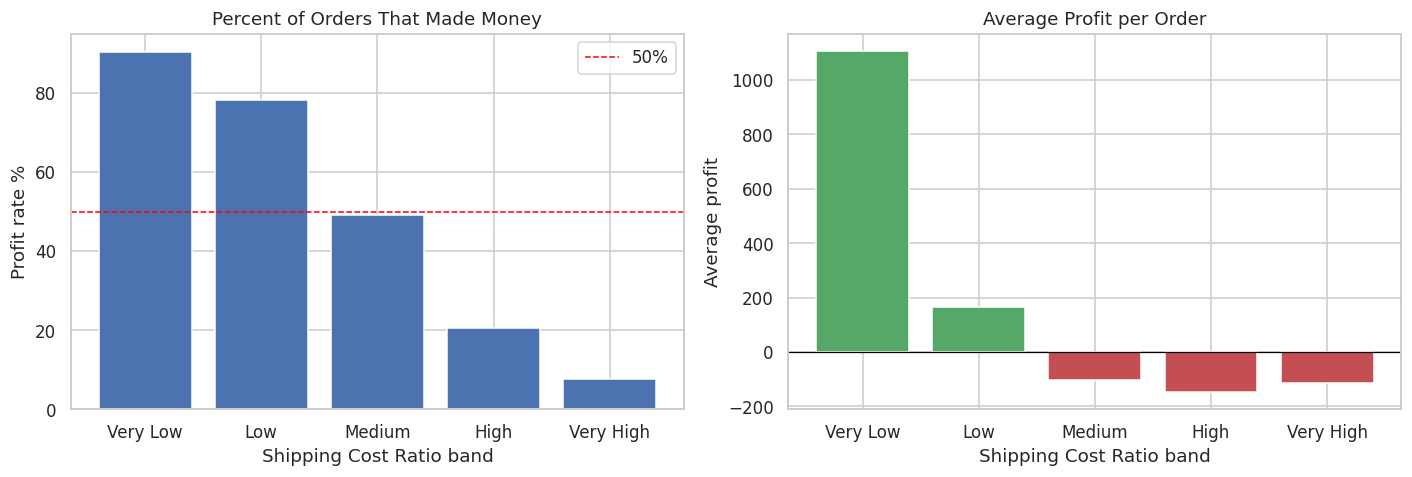

,Orders,Profit_Rate,Avg_Profit
Shipping Cost Ratio,,,
Very Low,1680,90.4,1106.735
Low,1680,78.3,166.291
Medium,1679,49.1,-103.451
High,1680,20.6,-148.108
Very High,1680,7.7,-115.715


In [6]:
bands = pd.qcut(df["Shipping Cost Ratio"], q=5,
                labels=["Very Low", "Low", "Medium", "High", "Very High"])

band_stats = df.groupby(bands, observed=False).agg(
    Orders=("Profitable", "size"),
    Profit_Rate=("Profitable", "mean"),
    Avg_Profit=("Profit", "mean"),
).round(3)
band_stats["Profit_Rate"] = (band_stats["Profit_Rate"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(band_stats.index.astype(str), band_stats["Profit_Rate"], color="#4C72B0")
axes[0].axhline(50, color="red", linestyle="--", linewidth=1, label="50%")
axes[0].set_title("Percent of Orders That Made Money")
axes[0].set_ylabel("Profit rate %")
axes[0].set_xlabel("Shipping Cost Ratio band")
axes[0].legend()

colors = ["#C44E52" if v < 0 else "#55A868" for v in band_stats["Avg_Profit"]]
axes[1].bar(band_stats.index.astype(str), band_stats["Avg_Profit"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Average Profit per Order")
axes[1].set_ylabel("Average profit")
axes[1].set_xlabel("Shipping Cost Ratio band")

plt.tight_layout()
plt.savefig("screenshots/03_shipping_ratio_effect.png", bbox_inches="tight")
plt.show()

band_stats

### Observation
The direction is clear and the effect is large. Orders where shipping is a small share of the sale
make money most of the time. Orders where shipping is a large share mostly lose money. This is the
single strongest pattern in the whole dataset.

## 6. Where Do the Losses Sit?

The model explains what drives profit. A manager also needs to know which parts of the business are
worst affected.

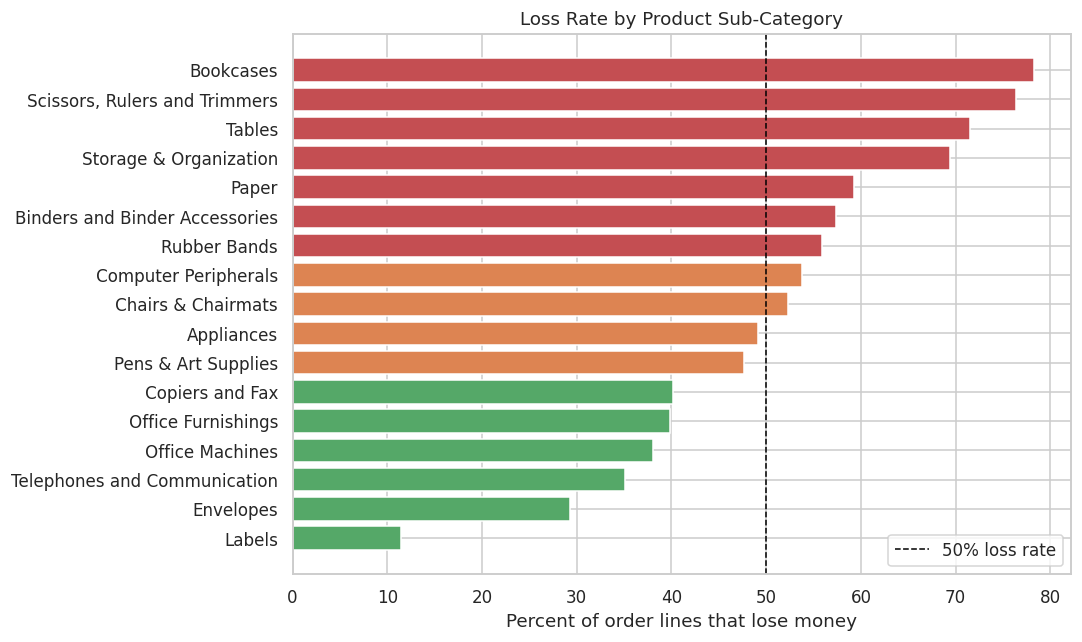

                                Orders  Loss_Rate  Total_Profit
Product Sub-Category                                           
Bookcases                          189       78.3      -33582.1
Scissors, Rulers and Trimmers      144       76.4       -7799.2
Tables                             361       71.5      -99062.5
Storage & Organization             546       69.4        6664.1
Paper                             1225       59.3       45263.2
Binders and Binder Accessories     915       57.4      307413.4
Rubber Bands                       179       55.9        -102.7
Computer Peripherals               758       53.8       94287.5


In [7]:
seg = df.groupby("Product Sub-Category").agg(
    Orders=("Profitable", "size"),
    Loss_Rate=("Profitable", lambda s: (1 - s.mean()) * 100),
    Total_Profit=("Profit", "sum"),
).round(1).sort_values("Loss_Rate", ascending=False)

plt.figure(figsize=(10, 6))
colors = ["#C44E52" if v > 55 else "#DD8452" if v > 45 else "#55A868"
          for v in seg["Loss_Rate"]]
plt.barh(seg.index[::-1], seg["Loss_Rate"][::-1], color=colors[::-1])
plt.axvline(50, color="black", linestyle="--", linewidth=1, label="50% loss rate")
plt.title("Loss Rate by Product Sub-Category")
plt.xlabel("Percent of order lines that lose money")
plt.legend()
plt.tight_layout()
plt.savefig("screenshots/04_loss_rate_by_subcategory.png", bbox_inches="tight")
plt.show()

print(seg.head(8).to_string())

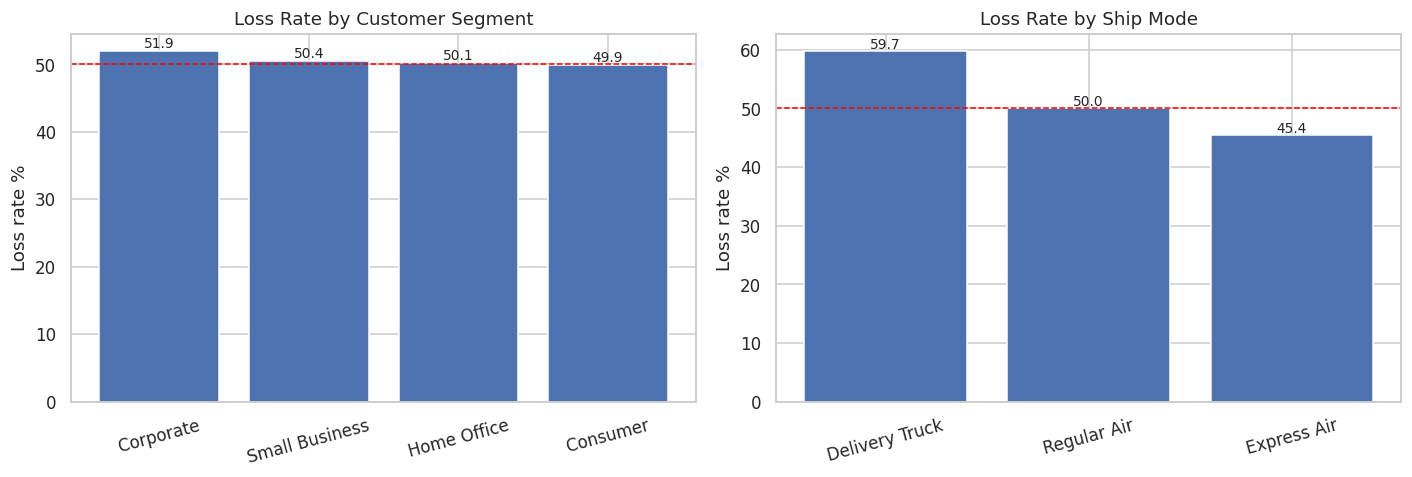

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col in zip(axes, ["Customer Segment", "Ship Mode"]):
    grp = df.groupby(col)["Profitable"].mean()
    grp = ((1 - grp) * 100).round(1).sort_values(ascending=False)
    ax.bar(grp.index, grp.values, color="#4C72B0")
    ax.axhline(50, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Loss Rate by {col}")
    ax.set_ylabel("Loss rate %")
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(grp.values):
        ax.text(i, v + 0.5, f"{v}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("screenshots/05_loss_rate_by_segment.png", bbox_inches="tight")
plt.show()

## 7. Checking the Interpretation

A simple way to test whether the importance ranking is real: shuffle the top feature so its values
become meaningless, and see how much the model gets worse. If `Shipping Cost Ratio` really is the
main driver, scrambling it should hurt a lot.

In [9]:
baseline_auc = roc_auc_score(y_test, proba)

rng = np.random.default_rng(0)

X_shuffled = X_test.copy()
X_shuffled["Shipping Cost Ratio"] = rng.permutation(X_shuffled["Shipping Cost Ratio"].values)
auc_top = roc_auc_score(y_test, model.predict_proba(X_shuffled)[:, 1])

X_shuffled2 = X_test.copy()
X_shuffled2["Order Month"] = rng.permutation(X_shuffled2["Order Month"].values)
auc_weak = roc_auc_score(y_test, model.predict_proba(X_shuffled2)[:, 1])

print(f"Normal ROC-AUC                        : {baseline_auc:.4f}")
print(f"After shuffling Shipping Cost Ratio   : {auc_top:.4f}")
print(f"After shuffling Order Month (weak)    : {auc_weak:.4f}")
print()
print(f"Damage from the top feature : {baseline_auc - auc_top:.4f}")
print(f"Damage from the weak feature: {baseline_auc - auc_weak:.4f}")

Normal ROC-AUC                        : 0.9888
After shuffling Shipping Cost Ratio   : 0.8716
After shuffling Order Month (weak)    : 0.9887

Damage from the top feature : 0.1172
Damage from the weak feature: 0.0001


### Observation
Scrambling `Shipping Cost Ratio` damages the model far more than scrambling a low-importance
feature like `Order Month`. That confirms the importance ranking is describing something real
rather than being an artifact of how the chart was drawn.

## 8. Business Report

*Written for a non-technical reader.*

### What was built
A model that looks at an order and predicts whether it will make money or lose money, before the
order is completed. It gets this right about **95 times out of 100** on orders it has never seen
before.

### Why it matters
Just over **half of all order lines currently lose money**. Sales figures look healthy while profit
does not, and the gap between the two is the main problem in this business.

### Key drivers
The model relies on a small number of factors:

1. **Shipping cost as a share of the sale.** This is by far the biggest driver. Orders where
   shipping takes a small share of the sale value make money most of the time. Orders where
   shipping takes a large share mostly lose money.
2. **Revenue per unit.** Cheap items are riskier than expensive ones, because the shipping and
   handling cost does not shrink in proportion to the price.
3. **Product base margin and product sub-category.** Profitability is very uneven across the
   catalogue. Some sub-categories lose money as a general rule, not by accident.
4. **Discount value.** The actual money given away matters more than the discount percentage.

### Risks
- **The data has no cost-of-goods column.** The model estimates profitability from price, discount
  and shipping. If purchase costs change, its judgement will be wrong without any warning.
- **The model makes mistakes in both directions.** On the test set it approved 32 orders that
  actually lost money, and flagged 59 profitable orders as risky. Used as an automatic reject rule,
  it would turn away good business.
- **It is based on past data.** A change in pricing or shipping policy would make parts of it
  out of date.
- **It shows patterns, not causes.** The model shows that loss-making orders tend to have high
  shipping ratios. It does not prove that reducing shipping cost would make those orders
  profitable.

### Limitations
- No cost-of-goods data, which limits how accurate any model can be here.
- Predictions are made per order line, not per customer, so an order that loses money but wins a
  valuable long-term customer looks like a plain failure.
- The model was not tuned, so it is probably not at its best.
- Customer history is not used at all.

### Recommended actions
1. **Look at shipping costs on cheap, bulky products first.** This is the strongest driver in the
   model and it is something the business can directly control, through minimum order sizes,
   shipping charges, or better carrier rates.
2. **Review the loss-making sub-categories, starting with Tables.** Tables alone loses 99,062, and
   over 70 percent of its order lines are unprofitable. This action needs no model, just a decision
   to act on the numbers.
3. **Check the margin before approving a discount.** Discount value shows up as a driver, and
   discounts are currently applied without reference to the margin underneath.
4. **Use the model as a warning, not as an automatic reject.** Flag risky orders for a person to
   review. Because the model makes mistakes in both directions, letting it reject orders on its own
   would cost the business real sales.
5. **Start recording cost of goods.** Most of the limitations above come back to this one missing
   piece of data.

## 9. Summary and Reflection

### What I learned
- Feature importance is easy to produce but it only tells half the story. It says a feature matters,
  not whether high values are good or bad. Splitting the top feature into bands was what actually
  made the finding usable.
- The most important feature in the model was one I created in Task 1, not one that came with the
  dataset. That was a good lesson in why feature engineering is worth the effort.
- Testing the interpretation by shuffling a feature was a simple check that made the conclusion much
  more convincing than just showing a bar chart.

### Limitations of this interpretation
- Random Forest's built-in importance is known to favour numeric features with many possible values
  over categorical ones, so the ranking may slightly understate the categorical columns.
- Each feature was examined on its own. Features can work together in ways this approach does not
  show.
- The analysis explains what the model does, which is not the same as explaining what actually
  causes profit in the business.

### Next steps
1. Use permutation importance as a second opinion, since it is measured on test data and is less
   prone to the bias mentioned above.
2. Look at pairs of features together rather than one at a time.
3. Attach real money figures to the model's decisions, so the recommendations can be stated as an
   expected saving rather than just a percentage.
4. Re-check the model on newer orders after a few months, since business conditions change.